In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_auc_score, roc_curve)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

# Charger le dataset genere par le Notebook 1
df = pd.read_csv('dataset.csv', dtype={
    'type_valeur':       str,
    'code_banque_don':   str,
    'code_banque_dest':  str,
    'situation_donneur': str,
    'type_compte':       str,
    'code_rejet':        str,
})

print(f'Dataset charge : {df.shape[0]} lignes x {df.shape[1]} colonnes')
print(f'Rejets : {df["a_ete_rejete"].sum()} ({df["a_ete_rejete"].mean()*100:.2f}%)')
print()
print('Apercu :')
df.head(3)

Dataset charge : 10000 lignes x 16 colonnes
Rejets : 1280 (12.80%)

Apercu :


,id,type_valeur,montant,code_banque_don,code_banque_dest,rib_donneur,rib_beneficiaire,rib_donneur_valide,rib_beneficiaire_valide,date_operation,echeance_depassee,meme_banque,situation_donneur,type_compte,a_ete_rejete,code_rejet
0,1,40,454.323,12,05,12898367203173155967,5772519193768741402,1,1,20260312,0,0,0,1,0,00
1,2,20,2837.951,26,17,26129772072204969839,17028687106674275240,1,1,20260424,0,0,0,1,0,00
2,3,10,3169.578,02,25,2554260334663625118,25682845396860088359,1,1,20260414,0,0,0,1,0,00


In [2]:
# 10 features qu'on garde pour le modele (toutes calculables en production)
FEATURES = [
    'type_valeur', 'montant',
    'code_banque_don', 'code_banque_dest',
    'rib_donneur_valide', 'rib_beneficiaire_valide',
    'echeance_depassee', 'meme_banque',
    'situation_donneur', 'type_compte',
]

# Variables categorielles a encoder en chiffres
COLS_CAT = ['type_valeur', 'code_banque_don', 'code_banque_dest',
            'situation_donneur', 'type_compte']

# X = features, y = cible
X = df[FEATURES].copy()
y = df['a_ete_rejete']

# Encodage des categorielles : texte -> chiffres
encoders = {}
for col in COLS_CAT:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    encoders[col] = le

print('Features encodees :')
for i, f in enumerate(FEATURES, 1):
    encode = '(encode)' if f in COLS_CAT else ''
    print(f'  {i:2d}. {f:30s} {encode}')

print(f'\nForme finale : X = {X.shape}, y = {y.shape}')
print(f'\nApercu apres encodage :')
X.head(3)

Features encodees :
   1. type_valeur                    (encode)
   2. montant                        
   3. code_banque_don                (encode)
   4. code_banque_dest               (encode)
   5. rib_donneur_valide             
   6. rib_beneficiaire_valide        
   7. echeance_depassee              
   8. meme_banque                    
   9. situation_donneur              (encode)
  10. type_compte                    (encode)

Forme finale : X = (10000, 10), y = (10000,)

Apercu apres encodage :


,type_valeur,montant,code_banque_don,code_banque_dest,rib_donneur_valide,rib_beneficiaire_valide,echeance_depassee,meme_banque,situation_donneur,type_compte
0,5,454.323,9,4,1,1,0,0,0,0
1,1,2837.951,14,11,1,1,0,0,0,0
2,0,3169.578,1,13,1,1,0,0,0,0


In [3]:
# ────────────────────────────────────────────────────────
# 1. Train/Test split (80% entrainement, 20% test)
# ────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,            # 20% pour le test
    random_state=42,          # graine pour reproductibilite
    stratify=y                # garde meme proportion de rejets dans train et test
)

print(f'Train : {len(X_train):>5} lignes ({y_train.mean()*100:.1f}% rejets)')
print(f'Test  : {len(X_test):>5} lignes ({y_test.mean()*100:.1f}% rejets)')
print()

# ────────────────────────────────────────────────────────
# 2. Entrainement Random Forest
# ────────────────────────────────────────────────────────
print('Entrainement en cours...')

rf = RandomForestClassifier(
    n_estimators=200,           # 200 arbres de decision
    max_depth=12,               # profondeur max d'un arbre
    min_samples_split=10,       # min 10 echantillons pour creer une branche
    min_samples_leaf=5,         # min 5 echantillons par feuille
    class_weight='balanced',    # gere le desequilibre 87% / 13%
    random_state=42,            # reproductibilite
    n_jobs=-1,                  # utilise tous les coeurs CPU
)
rf.fit(X_train, y_train)

print(f'Modele entraine !')
print(f'  - Nombre d arbres   : {rf.n_estimators}')
print(f'  - Profondeur max    : {rf.max_depth}')
print(f'  - Nombre de features: {rf.n_features_in_}')

Train :  8000 lignes (12.8% rejets)
Test  :  2000 lignes (12.8% rejets)

Entrainement en cours...
Modele entraine !
  - Nombre d arbres   : 200
  - Profondeur max    : 12
  - Nombre de features: 10


  PERFORMANCES SUR LE SET DE TEST (2000 transactions)
  Accuracy  :  98.20%   (% de predictions correctes)
  Precision :  90.44%   (parmi les rejets predits, combien sont vrais)
  Recall    :  96.09%   (parmi les vrais rejets, combien sont detectes)
  F1-Score  :  93.18%   (equilibre Precision/Recall)
  AUC-ROC   :  97.30%   (qualite globale du classifieur)

Rapport detaille :
              precision    recall  f1-score   support

     Accepte       0.99      0.99      0.99      1744
      Rejete       0.90      0.96      0.93       256

    accuracy                           0.98      2000
   macro avg       0.95      0.97      0.96      2000
weighted avg       0.98      0.98      0.98      2000



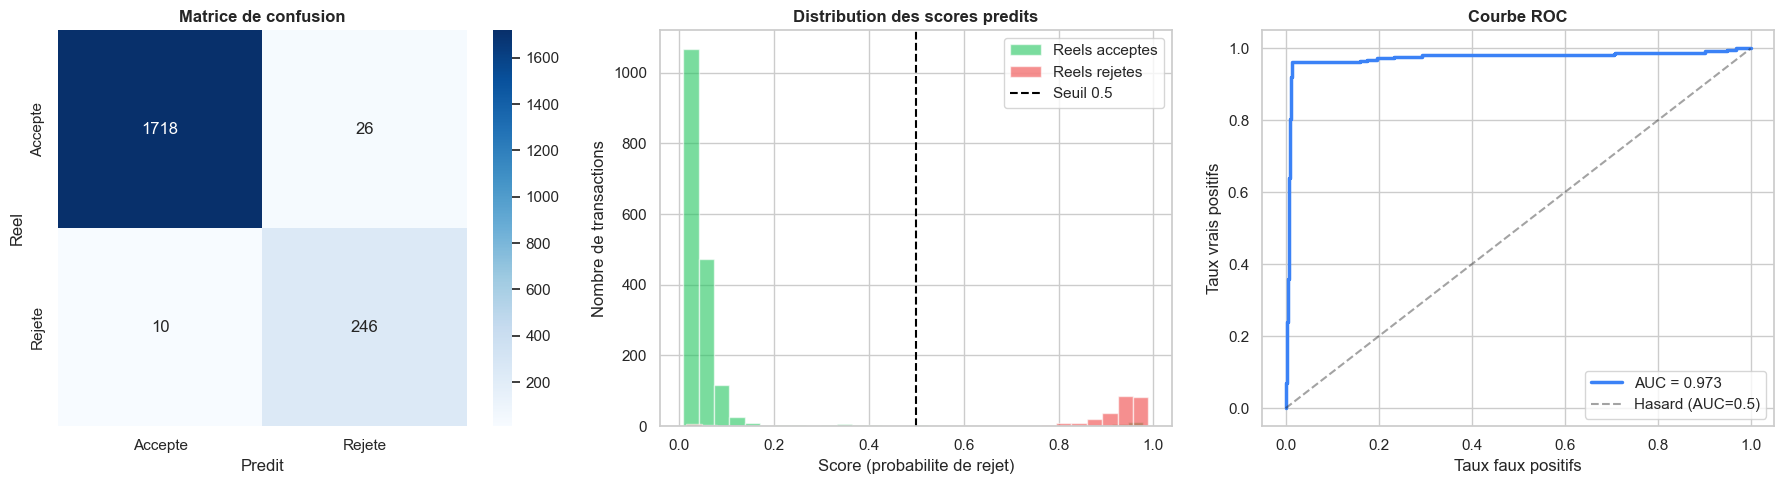

Graphique sauvegarde : evaluation_modele.png


In [4]:
# Predictions sur le set de test
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

# ────────────────────────────────────────────────────────
# Metriques principales
# ────────────────────────────────────────────────────────
print('=' * 55)
print('  PERFORMANCES SUR LE SET DE TEST (2000 transactions)')
print('=' * 55)
print(f'  Accuracy  : {accuracy_score(y_test, y_pred)*100:6.2f}%   (% de predictions correctes)')
print(f'  Precision : {precision_score(y_test, y_pred)*100:6.2f}%   (parmi les rejets predits, combien sont vrais)')
print(f'  Recall    : {recall_score(y_test, y_pred)*100:6.2f}%   (parmi les vrais rejets, combien sont detectes)')
print(f'  F1-Score  : {f1_score(y_test, y_pred)*100:6.2f}%   (equilibre Precision/Recall)')
print(f'  AUC-ROC   : {roc_auc_score(y_test, y_proba)*100:6.2f}%   (qualite globale du classifieur)')
print()
print('Rapport detaille :')
print(classification_report(y_test, y_pred, target_names=['Accepte', 'Rejete']))

# ────────────────────────────────────────────────────────
# Visualisations (3 graphiques cote a cote)
# ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Accepte', 'Rejete'],
            yticklabels=['Accepte', 'Rejete'])
axes[0].set_title('Matrice de confusion', fontweight='bold')
axes[0].set_ylabel('Reel')
axes[0].set_xlabel('Predit')

# 2. Distribution des scores de probabilite
axes[1].hist(y_proba[y_test==0], bins=30, alpha=0.6, color='#22c55e', label='Reels acceptes')
axes[1].hist(y_proba[y_test==1], bins=30, alpha=0.6, color='#ef4444', label='Reels rejetes')
axes[1].axvline(0.5, color='black', linestyle='--', label='Seuil 0.5')
axes[1].set_title('Distribution des scores predits', fontweight='bold')
axes[1].set_xlabel('Score (probabilite de rejet)')
axes[1].set_ylabel('Nombre de transactions')
axes[1].legend()

# 3. Courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
axes[2].plot(fpr, tpr, color='#3b82f6', lw=2.5, label=f'AUC = {auc:.3f}')
axes[2].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Hasard (AUC=0.5)')
axes[2].set_title('Courbe ROC', fontweight='bold')
axes[2].set_xlabel('Taux faux positifs')
axes[2].set_ylabel('Taux vrais positifs')
axes[2].legend(loc='lower right')

plt.tight_layout()
plt.savefig('evaluation_modele.png', dpi=120, bbox_inches='tight')
plt.show()

print('Graphique sauvegarde : evaluation_modele.png')

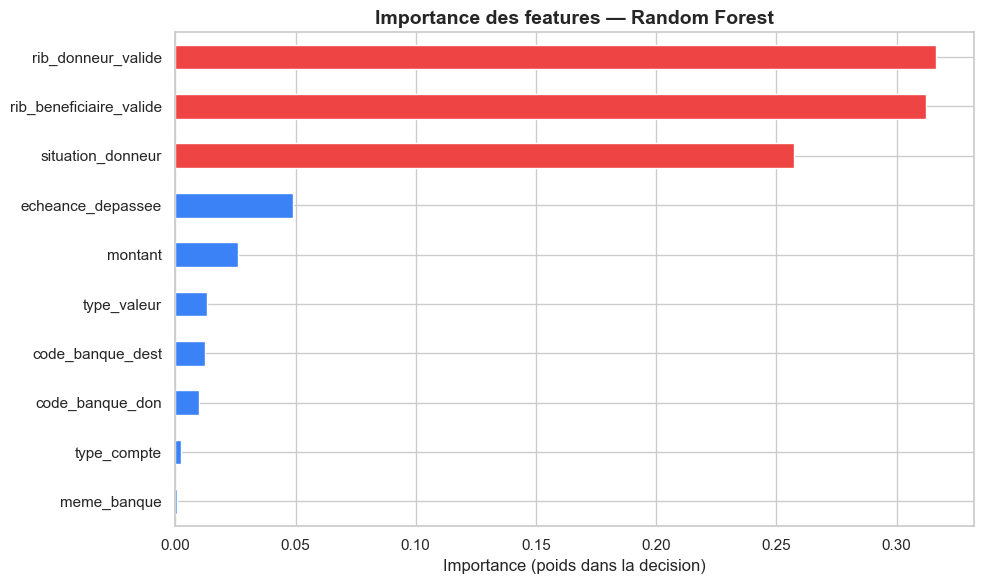

Classement des features (de la plus importante a la moins importante) :
  rib_donneur_valide             0.3164  ###############################
  rib_beneficiaire_valide        0.3124  ###############################
  situation_donneur              0.2572  #########################
  echeance_depassee              0.0491  ####
  montant                        0.0260  ##
  type_valeur                    0.0132  #
  code_banque_dest               0.0125  #
  code_banque_don                0.0100  
  type_compte                    0.0024  
  meme_banque                    0.0008  

  CROSS-VALIDATION 5-FOLD
On entraine le modele 5 fois sur des decoupages differents
pour verifier que les performances sont stables...

F1-Score par fold : ['0.922', '0.934', '0.929', '0.920', '0.920']
F1 moyen          : 0.925 (+/- 0.006)

Modele tres stable - aucun signe de sur-apprentissage


In [5]:
# ────────────────────────────────────────────────────────
# 1. Feature Importance — Quelles features le modele utilise ?
# ────────────────────────────────────────────────────────
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(10, 6))
colors = ['#ef4444' if v > 0.15 else '#f59e0b' if v > 0.08 else '#3b82f6' for v in imp]
imp.plot(kind='barh', color=colors, edgecolor='white')
plt.title('Importance des features — Random Forest', fontweight='bold', fontsize=14)
plt.xlabel('Importance (poids dans la decision)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print('Classement des features (de la plus importante a la moins importante) :')
print('=' * 65)
for feat, val in imp.sort_values(ascending=False).items():
    bar = '#' * int(val * 100)
    print(f'  {feat:30s} {val:.4f}  {bar}')

# ────────────────────────────────────────────────────────
# 2. Cross-validation — Le modele est-il stable ?
# ────────────────────────────────────────────────────────
print()
print('=' * 65)
print('  CROSS-VALIDATION 5-FOLD')
print('=' * 65)
print('On entraine le modele 5 fois sur des decoupages differents')
print('pour verifier que les performances sont stables...')
print()

cv = cross_val_score(rf, X, y, cv=5, scoring='f1', n_jobs=-1)

print(f'F1-Score par fold : {[f"{s:.3f}" for s in cv]}')
print(f'F1 moyen          : {cv.mean():.3f} (+/- {cv.std():.3f})')
print()

if cv.std() < 0.02:
    print('Modele tres stable - aucun signe de sur-apprentissage')
elif cv.std() < 0.05:
    print('Modele stable - performances coherentes')
else:
    print('ATTENTION : variance elevee, verifier les donnees')

In [6]:
# ────────────────────────────────────────────────────────
# Sauvegarde du modele et des encodeurs
# ────────────────────────────────────────────────────────

# 1. Sauvegarder le modele Random Forest
with open('model.pkl', 'wb') as f:
    pickle.dump(rf, f)

# 2. Sauvegarder les encodeurs (necessaires pour Flask)
with open('encoders.pkl', 'wb') as f:
    pickle.dump(encoders, f)

print('=' * 55)
print('  EXPORT TERMINE')
print('=' * 55)
print()
print(f'  model.pkl     : {rf.n_estimators} arbres, {rf.n_features_in_} features')
print(f'  encoders.pkl  : {len(encoders)} encodeurs categoriels')
print()
print('=' * 55)
print('  PIPELINE COMPLET TERMINE')
print('=' * 55)
print()
print('Fichiers prets dans C:\\Users\\hosni\\telecompensation\\ml\\ :')
print('   - model.pkl      (modele entraine)')
print('   - encoders.pkl   (encodeurs categoriels)')
print('   - app.py         (deja en place, sera adapte ensuite)')
print()
print('Prochaine etape :')
print('   1. Adapter app.py pour utiliser les 10 nouvelles features')
print('   2. Adapter Laravel (FichierTraitementService.php)')
print('   3. Relancer Flask et tester')
print()
print('Pour relancer Flask depuis cmd :')
print('   cd C:\\Users\\hosni\\telecompensation\\ml')
print('   python app.py')

  EXPORT TERMINE

  model.pkl     : 200 arbres, 10 features
  encoders.pkl  : 5 encodeurs categoriels

  PIPELINE COMPLET TERMINE

Fichiers prets dans C:\Users\hosni\telecompensation\ml\ :
   - model.pkl      (modele entraine)
   - encoders.pkl   (encodeurs categoriels)
   - app.py         (deja en place, sera adapte ensuite)

Prochaine etape :
   1. Adapter app.py pour utiliser les 10 nouvelles features
   2. Adapter Laravel (FichierTraitementService.php)
   3. Relancer Flask et tester

Pour relancer Flask depuis cmd :
   cd C:\Users\hosni\telecompensation\ml
   python app.py
